# 04_05 Classification - GBTClassifier
Train and evaluate GBTClassifier.

[COMMAND_SO]
Command 1

[COMMAND_MUC_DICH]
- Muc tieu nghiep vu: Train GBTClassifier va visual ket qua danh gia tren test set.
- Muc tieu ky thuat: Hien thi metric table va confusion matrix trong notebook.

26/04/05 18:18:00 WARN Utils: Your hostname, Genius-Macbook.local resolves to a loopback address: 127.0.0.1; using 10.178.74.160 instead (on interface en0)
26/04/05 18:18:00 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/05 18:18:01 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/04/05 18:18:02 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/04/05 18:18:02 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.
26/04/05 18:18:02 WARN Utils: Service 'SparkUI' could not bind on port 4042. Attempting port 4043.
26/04/05 18:18:02 WARN Utils: Service 'SparkUI' could not bind on port 4043. Attempting port 4044.
26/04/05 18:18:02 WARN Utils: Service 'SparkUI' could not bind on port 4044. Attempting

Before oversampling: class_0=52584, class_1=17025, ratio=3.09
After oversampling: 105187 rows


26/04/05 18:19:16 WARN DAGScheduler: Broadcasting large task binary with size 1004.0 KiB
26/04/05 18:19:16 WARN DAGScheduler: Broadcasting large task binary with size 1011.2 KiB
26/04/05 18:19:16 WARN DAGScheduler: Broadcasting large task binary with size 1010.3 KiB
26/04/05 18:19:16 WARN DAGScheduler: Broadcasting large task binary with size 1010.8 KiB
26/04/05 18:19:16 WARN DAGScheduler: Broadcasting large task binary with size 1011.5 KiB
26/04/05 18:19:17 WARN DAGScheduler: Broadcasting large task binary with size 1012.5 KiB
26/04/05 18:19:17 WARN DAGScheduler: Broadcasting large task binary with size 1014.2 KiB
26/04/05 18:19:17 WARN DAGScheduler: Broadcasting large task binary with size 1017.0 KiB
26/04/05 18:19:17 WARN DAGScheduler: Broadcasting large task binary with size 1021.7 KiB
26/04/05 18:19:17 WARN DAGScheduler: Broadcasting large task binary with size 1028.9 KiB
26/04/05 18:19:18 WARN DAGScheduler: Broadcasting large task binary with size 1028.3 KiB
26/04/05 18:19:18 WAR

{'model_family': 'classification', 'model_name': 'GBTClassifier', 'val_f1': 0.849412854929085, 'val_accuracy': 0.8545856798069188, 'val_precision': 0.8466685088579837, 'val_recall': 0.8545856798069187, 'f1': 0.8597954729929868, 'accuracy': 0.863703405738804, 'precision': 0.8572780188033552, 'recall': 0.863703405738804, 'test_f1': 0.8597954729929868, 'test_accuracy': 0.863703405738804, 'test_precision': 0.8572780188033552, 'test_recall': 0.863703405738804, 'train_rows': 105187, 'val_rows': 14916, 'test_rows': 14916}


,model_family,model_name,val_f1,val_accuracy,val_precision,val_recall,f1,accuracy,precision,recall,test_f1,test_accuracy,test_precision,test_recall,train_rows,val_rows,test_rows
0,classification,GBTClassifier,0.849413,0.854586,0.846669,0.854586,0.859795,0.863703,0.857278,0.863703,0.859795,0.863703,0.857278,0.863703,105187,14916,14916


26/04/05 18:19:37 WARN DAGScheduler: Broadcasting large task binary with size 1175.7 KiB
26/04/05 18:19:38 WARN DAGScheduler: Broadcasting large task binary with size 1163.8 KiB


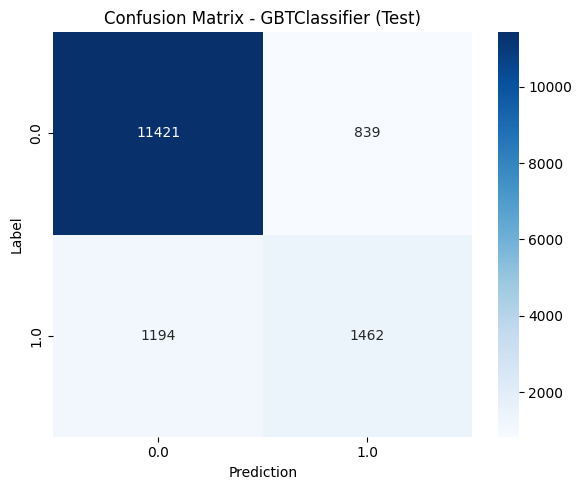

556

In [1]:
from pathlib import Path
import json
from pyspark.sql import SparkSession
from pyspark.ml.classification import GBTClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
spark=(SparkSession.builder.appName('04_05_gbt_cls').master('local[2]').config('spark.sql.shuffle.partitions','16').getOrCreate())
spark.sparkContext.setLogLevel('WARN')
PROJECT_ROOT=Path.cwd().resolve().parent if Path.cwd().name=='notebooks' else Path.cwd().resolve()
FEATURE_DIR=PROJECT_ROOT/'data'/'processed'/'features'
MODEL_DIR=PROJECT_ROOT/'models'/'classification'/'gbt_classifier'
METRIC_DIR=PROJECT_ROOT/'reports'/'model_metrics'
MODEL_DIR.mkdir(parents=True, exist_ok=True)
METRIC_DIR.mkdir(parents=True, exist_ok=True)
train_df=spark.read.parquet(str(FEATURE_DIR/'classification_train')).select('order_id','label','features').dropna()
# --- Oversample minority class (class 1) to handle class imbalance ---
_c0 = train_df.filter(train_df['label'] == 0)
_c1 = train_df.filter(train_df['label'] == 1)
_n0, _n1 = _c0.count(), _c1.count()
print(f'Before oversampling: class_0={_n0}, class_1={_n1}, ratio={_n0/_n1:.2f}')
train_df = _c0.unionAll(_c1.sample(withReplacement=True, fraction=_n0/_n1, seed=42))
print(f'After oversampling: {train_df.count()} rows')
val_df=spark.read.parquet(str(FEATURE_DIR/'classification_val')).select('order_id','label','features').dropna()
test_df=spark.read.parquet(str(FEATURE_DIR/'classification_test')).select('order_id','label','features').dropna()
gbt=GBTClassifier(featuresCol='features',labelCol='label',maxDepth=8,maxIter=60,stepSize=0.1,seed=42)
m=gbt.fit(train_df)
pred_val=m.transform(val_df)
pred_test=m.transform(test_df)
val_f1=MulticlassClassificationEvaluator(labelCol='label',predictionCol='prediction',metricName='f1').evaluate(pred_val)
val_acc=MulticlassClassificationEvaluator(labelCol='label',predictionCol='prediction',metricName='accuracy').evaluate(pred_val)
test_f1=MulticlassClassificationEvaluator(labelCol='label',predictionCol='prediction',metricName='f1').evaluate(pred_test)
test_acc=MulticlassClassificationEvaluator(labelCol='label',predictionCol='prediction',metricName='accuracy').evaluate(pred_test)
val_precision=MulticlassClassificationEvaluator(labelCol='label',predictionCol='prediction',metricName='weightedPrecision').evaluate(pred_val)
val_recall=MulticlassClassificationEvaluator(labelCol='label',predictionCol='prediction',metricName='weightedRecall').evaluate(pred_val)
test_precision=MulticlassClassificationEvaluator(labelCol='label',predictionCol='prediction',metricName='weightedPrecision').evaluate(pred_test)
test_recall=MulticlassClassificationEvaluator(labelCol='label',predictionCol='prediction',metricName='weightedRecall').evaluate(pred_test)
metrics={'model_family':'classification','model_name':'GBTClassifier','val_f1':float(val_f1),'val_accuracy':float(val_acc),'val_precision':float(val_precision),'val_recall':float(val_recall),'f1':float(test_f1),'accuracy':float(test_acc),'precision':float(test_precision),'recall':float(test_recall),'test_f1':float(test_f1),'test_accuracy':float(test_acc),'test_precision':float(test_precision),'test_recall':float(test_recall),'train_rows':train_df.count(),'val_rows':val_df.count(),'test_rows':test_df.count()}
print(metrics)
display(pd.DataFrame([metrics]))
cm_pdf=pred_test.groupBy('label','prediction').count().toPandas()
if not cm_pdf.empty:
    cm_table=cm_pdf.pivot(index='label', columns='prediction', values='count').fillna(0).sort_index().sort_index(axis=1)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm_table, annot=True, fmt='.0f', cmap='Blues')
    plt.title('Confusion Matrix - GBTClassifier (Test)')
    plt.xlabel('Prediction')
    plt.ylabel('Label')
    plt.tight_layout()
    plt.show()
m.write().overwrite().save(str(MODEL_DIR))
(METRIC_DIR/'classification_gbt_classifier.json').write_text(json.dumps(metrics,indent=2),encoding='utf-8')